/usr/local/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: One or several characters couldn't be converted correctly from SJIS to UTF-8.  This warning will not be emitted anymore
  return ogr_read(
/tmp/ipykernel_11981/3130336047.py:94: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


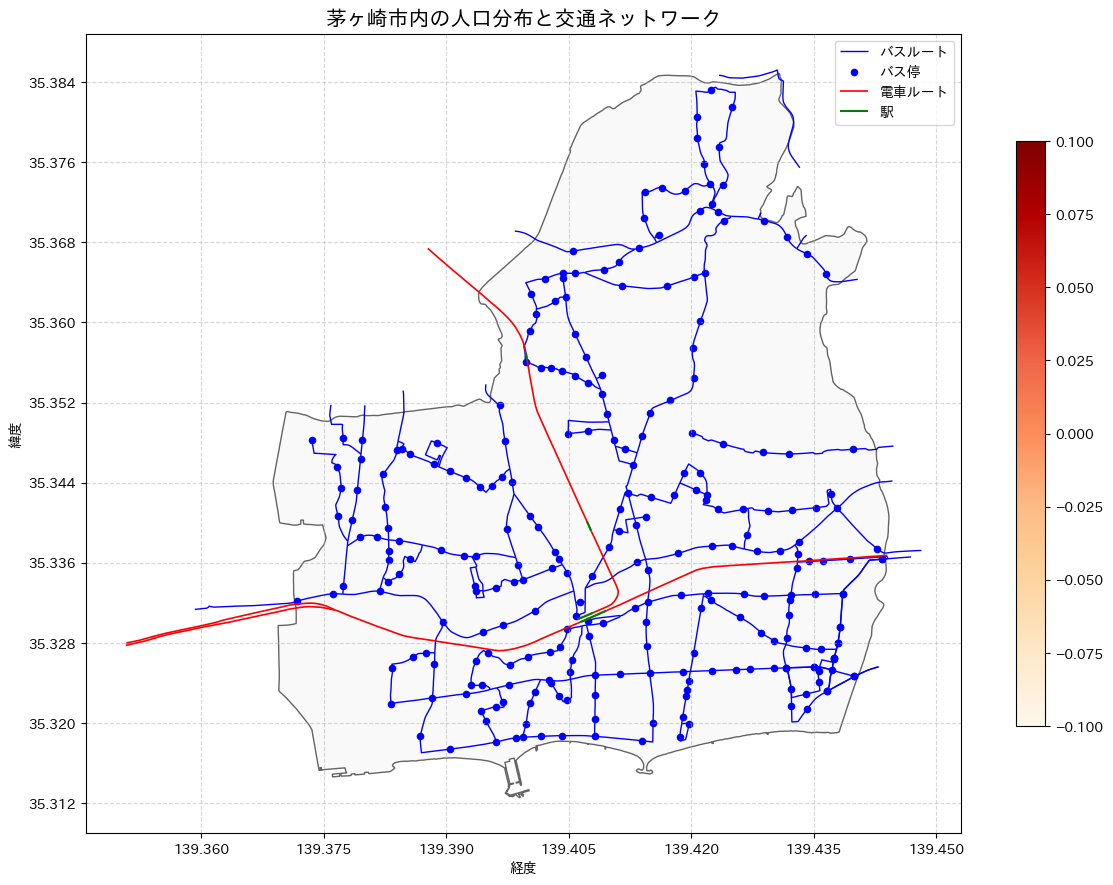

In [301]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. メッシュデータの読み込みと統合
# ==========================================
mesh_files = [
    "../data/tmp/merge/MESH05239.shp",
    "../data/tmp/merge/MESH05238.shp",
    "../data/tmp/merge/MESH05339.shp",
    "../data/tmp/merge/MESH05338.shp",
]
mesh_gdf = pd.concat([gpd.read_file(f) for f in mesh_files], ignore_index=True)

# 測地系を統一（JGD2011 EPSG:6668）
target_crs = "EPSG:6668"
mesh_gdf = mesh_gdf.to_crs(target_crs)
mesh_gdf["KEY_CODE"] = mesh_gdf["KEY_CODE"].astype(str)

# ==========================================
# 2. 人口データ読み込み
# ==========================================
pop_df = pd.read_table("../data/poplation/人口.txt", encoding="shift-jis", sep=",", header=1)
pop_df.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df["KEY_CODE"] = pop_df["KEY_CODE"].astype(str)
pop_df.columns = pop_df.columns.str.strip()

# ==========================================
# 3. 茅ヶ崎市ポリゴンの抽出
# ==========================================
kanagawa_gdf = gpd.read_file("../data/kanagawa_porigon/kanagawa.shp")
if kanagawa_gdf.crs is None:
    kanagawa_gdf.set_crs(target_crs, inplace=True)
kanagawa_gdf = kanagawa_gdf.to_crs(target_crs)
chigasaki_polygon = kanagawa_gdf.iloc[[880]]

# ==========================================
# 4. メッシュと人口データの結合
# ==========================================
pop_mesh_df = pd.merge(mesh_gdf, pop_df, on="KEY_CODE", how="left")
pop_mesh_df = pop_mesh_df[pop_mesh_df["geometry"].notnull()]
pop_mesh_gdf = gpd.GeoDataFrame(pop_mesh_df, geometry="geometry", crs=target_crs)

# ==========================================
# 5. 茅ヶ崎市内のデータ抽出（空間結合）
# ==========================================
chigasaki_pop_mesh_gdf = gpd.sjoin(pop_mesh_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# 駅とバス停の読み込み・抽出
train_stop_gdf = gpd.read_file("../data/train_stop/N02-22_Station.shp").to_crs(target_crs)
bus_stop_gdf = gpd.read_file("../data/bus_stop/busstop.shp").to_crs(target_crs)
chigasaki_train_stop_gdf = gpd.sjoin(train_stop_gdf, chigasaki_polygon, how="inner", predicate="intersects")
chigasaki_bus_stop_gdf = gpd.sjoin(bus_stop_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# 電車とバスのルート読み込み・抽出
train_route_gdf = gpd.read_file("../data/train_stop/N02-22_RailroadSection.shp").to_crs(target_crs)
bus_route_gdf = gpd.read_file("../data/bus_route/busroute.shp").to_crs(target_crs)
chigasaki_train_route_gdf = gpd.sjoin(train_route_gdf, chigasaki_polygon, how="inner", predicate="intersects")
chigasaki_bus_route_gdf = gpd.sjoin(bus_route_gdf, chigasaki_polygon, how="inner", predicate="intersects")

# ==========================================
# 6. プロット（可視化）
# ==========================================
fig, ax = plt.subplots(figsize=(12, 12))

# 茅ヶ崎市ポリゴン
chigasaki_polygon.plot(ax=ax, color="whitesmoke", edgecolor="black", alpha=0.6, label="茅ヶ崎市")

# メッシュ（人口で色分け）
chigasaki_pop_mesh_gdf.plot(
    ax=ax,
    column=chigasaki_pop_mesh_gdf.columns[10],
    cmap="OrRd",
    legend=True,
    legend_kwds={"shrink": 0.5},
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.3
)

# 駅・バス停・ルート
chigasaki_bus_route_gdf.plot(ax=ax, color="blue", linewidth=1, label="バスルート")
chigasaki_bus_stop_gdf.plot(ax=ax, color="blue", markersize=20, label="バス停")
chigasaki_train_route_gdf.plot(ax=ax, color="red", linewidth=1.2, label="電車ルート")
chigasaki_train_stop_gdf.plot(ax=ax, color="green", markersize=100, label="駅")

# 軸と凡例
ax.set_title("茅ヶ崎市内の人口分布と交通ネットワーク", fontsize=15)
ax.set_xlabel("経度")
ax.set_ylabel("緯度")
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<Axes: >

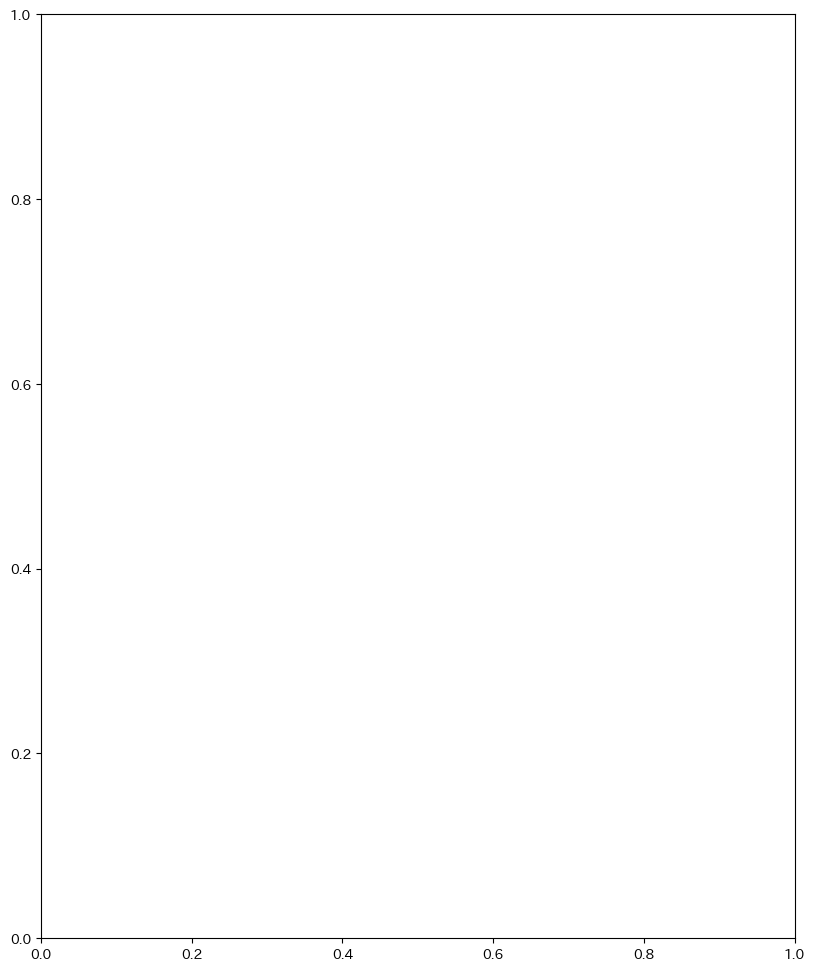

In [306]:
fig, ax = plt.subplots(figsize=(12, 12))

# メッシュ（人口で色分け）
chigasaki_pop_mesh_gdf.plot(
    ax=ax,
    column=chigasaki_pop_mesh_gdf.columns[10],
    cmap="raindbow"
)

In [ ]:
# ==========================================
# 1. メッシュデータの読み込みと統合
# ==========================================
mesh_files = [
    "../data/tmp/merge/MESH05239.shp",
    "../data/tmp/merge/MESH05238.shp",
    "../data/tmp/merge/MESH05339.shp",
    "../data/tmp/merge/MESH05338.shp",
]
mesh_gdf = pd.concat([gpd.read_file(f) for f in mesh_files], ignore_index=True)

# 測地系を統一（JGD2011 EPSG:6668）
target_crs = "EPSG:6668"
mesh_gdf = mesh_gdf.to_crs(target_crs)
mesh_gdf["KEY_CODE"] = mesh_gdf["KEY_CODE"].astype(str)

# ==========================================
# 2. 人口データ読み込み
# ==========================================
pop_df = pd.read_table("../data/poplation/.txt", encoding="shift-jis", sep=",", header=1)
pop_df.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df["KEY_CODE"] = pop_df["KEY_CODE"].astype(str)
pop_df.columns = pop_df.columns.str.strip()

# ==========================================
# 3. 茅ヶ崎市ポリゴンの抽出
# ==========================================
kanagawa_gdf = gpd.read_file("../data/kanagawa_porigon/kanagawa.shp")
if kanagawa_gdf.crs is None:
    kanagawa_gdf.set_crs(target_crs, inplace=True)
kanagawa_gdf = kanagawa_gdf.to_crs(target_crs)
chigasaki_polygon = kanagawa_gdf.iloc[[880]]

# ==========================================
# 4. メッシュと人口データの結合
# ==========================================
pop_mesh_df = pd.merge(mesh_gdf, pop_df, on="KEY_CODE", how="left")
#pop_mesh_df = pop_mesh_df[pop_mesh_df["geometry"].notnull()]
pop_mesh_gdf = gpd.GeoDataFrame(pop_mesh_df, geometry="geometry", crs=target_crs)

# ==========================================
# 5. 茅ヶ崎市内のデータ抽出（空間結合）
# ==========================================
chigasaki_pop_mesh_gdf = gpd.sjoin(pop_mesh_gdf, chigasaki_polygon, how="inner", predicate="intersects")


In [325]:
pd.merge(chigasaki_pop_mesh_gdf,pop_df, on="KEY_CODE", how="inner")

,KEY_CODE,MESH1_ID,MESH2_ID,MESH3_ID,MESH4_ID,OBJ_ID,geometry,Unnamed: 1_x,Unnamed: 2_x,Unnamed: 3_x,...,６人世帯数 一般世帯数_y,７人以上世帯数 一般世帯数_y,親族のみの世帯数 一般世帯数_y,核家族世帯数 一般世帯数_y,核家族以外の世帯数 一般世帯数_y,６歳未満世帯員のいる世帯数 一般世帯数_y,６５歳以上世帯員のいる世帯数 一般世帯数_y,世帯主の年齢が２０〜２９歳の１人世帯数 一般世帯数_y,高齢単身世帯数 一般世帯数_y,高齢夫婦世帯数 一般世帯数_y


In [ ]:
# ==========================================
# 2. 人口データ読み込み
# ==========================================
pop_df_1 = pd.read_table("../data/poplation/tblT001101H5238.txt", encoding="shift-jis", sep=",", header=1)
pop_df_1.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df_1["KEY_CODE"] = pop_df_1["KEY_CODE"].astype(str)
pop_df_1.columns = pop_df_1.columns.str.strip()

pop_df_2 = pd.read_table("../data/poplation/tblT001101H5238.txt", encoding="shift-jis", sep=",", header=1)
pop_df_2.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df_2["KEY_CODE"] = pop_df_2["KEY_CODE"].astype(str)
pop_df_2.columns = pop_df_2.columns.str.strip()

pop_df_3 = pd.read_table("../data/poplation/tblT001101H5238.txt", encoding="shift-jis", sep=",", header=1)
pop_df_3.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df_3["KEY_CODE"] = pop_df_3["KEY_CODE"].astype(str)
pop_df_3.columns = pop_df_3.columns.str.strip()

pop_df_4 = pd.read_table("../data/poplation/tblT001101H5238.txt", encoding="shift-jis", sep=",", header=1)
pop_df_4.rename(columns={"Unnamed: 0": "KEY_CODE"}, inplace=True)
pop_df_4["KEY_CODE"] = pop_df_4["KEY_CODE"].astype(str)
pop_df_4.columns = pop_df_4.columns.str.strip()